# Exploring the LLM-Seeded Text Embeddings

Before training Unicorn v2, let's look at what our text embedding initialization gives us.

We generated 3-4 sentence basketball identity descriptions for all 12,821 player-seasons using GPT-4o (prompt D4: archetype + team fit framing), **anonymized** them (stripped player names and year references), then embedded with OpenAI's `text-embedding-3-small` at dimension 384.

**Key questions:**
1. Do similar archetypes cluster together? (point guards near point guards, etc.)
2. Do same-player embeddings across seasons form coherent trajectories?
3. How much does the embedding space already "know" about basketball before any training?
4. What are the failure modes? Where does the text space get it wrong?

This is a **pre-training sanity check** — if the text embeddings are garbage, we shouldn't use them for initialization.

In [1]:
import csv
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load data
lu = pd.read_csv("player_season_lookup.csv")
emb = torch.load("player_text_embeddings.pt", map_location="cpu", weights_only=True)
base_emb = torch.load("base_player_text_embeddings.pt", map_location="cpu", weights_only=True)

# Load descriptions
descs = {}
with open("player_descriptions.jsonl") as f:
    for line in f:
        d = json.loads(line)
        descs[(d["player"], d["season"])] = d["description"]

# Load bbref → display name mapping
name_map = {}
with open("bbref_name_mapping.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        name_map[row["bbref_id"]] = row["display_name"]

def display_name(bbref_id):
    """Convert bbref ID to display name, with fallback."""
    return name_map.get(bbref_id, bbref_id)

# Build name mapping using display names
lu["display"] = lu["player"].map(display_name) + " (" + lu["season"].astype(str) + ")"
id_to_name = lu.set_index("player_season_id")["display"].to_dict()
id_to_player = lu.set_index("player_season_id")["player"].to_dict()
id_to_season = lu.set_index("player_season_id")["season"].to_dict()

# Normalize embeddings for cosine similarity
emb_norm = F.normalize(emb, dim=1)

print(f"Player-season embeddings: {emb.shape}")
print(f"Base player embeddings: {base_emb.shape}")
print(f"Descriptions loaded: {len(descs):,}")
print(f"Lookup table: {len(lu):,} rows")
print(f"Name mapping: {len(name_map):,} players ({len(name_map)/len(lu['player'].unique())*100:.1f}% coverage)")

Player-season embeddings: torch.Size([12821, 384])
Base player embeddings: torch.Size([2310, 384])
Descriptions loaded: 12,821
Lookup table: 12,821 rows
Name mapping: 2,310 players (100.0% coverage)


## 1. Basic Embedding Statistics

Before anything fancy, let's look at the raw distribution of the embedding space.

Norm stats: mean=1.0000, std=0.000000, min=1.0000, max=1.0000


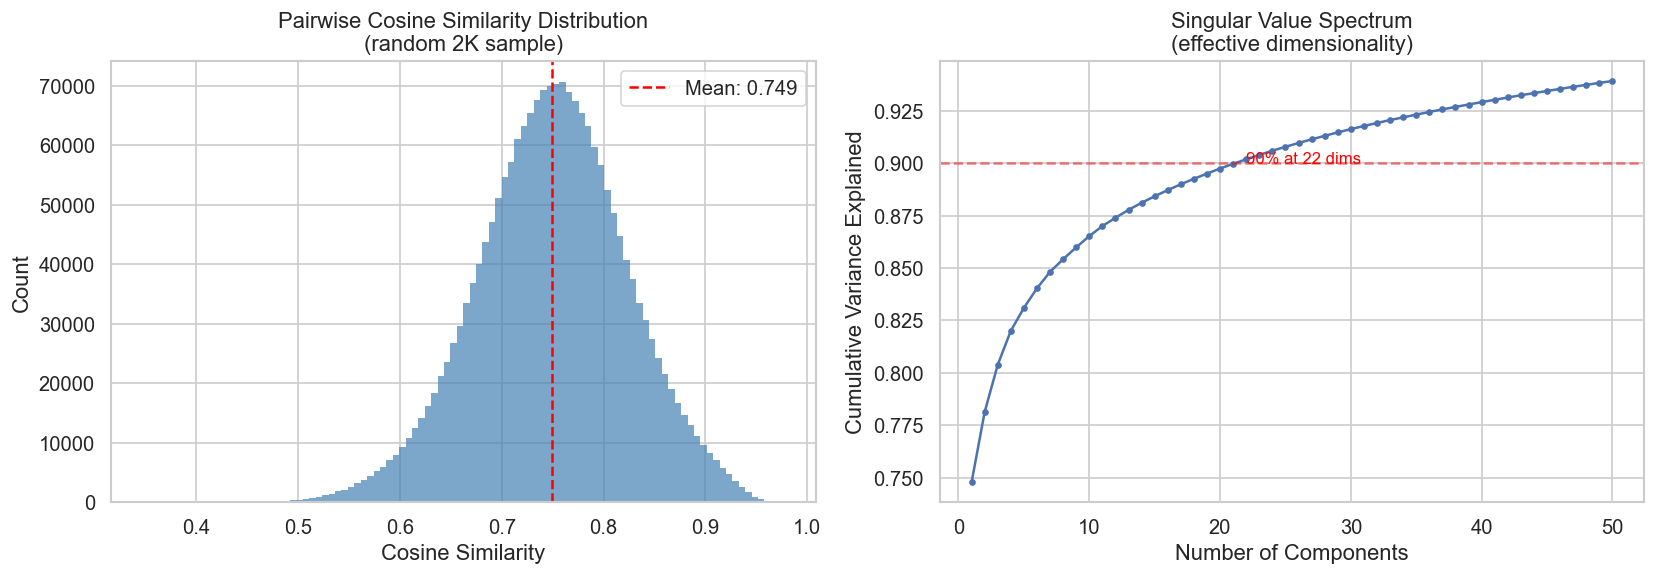


Pairwise sim: mean=0.7493, std=0.0737
90% variance explained by 22 of 384 dimensions
This tells us how 'spread out' the embedding space is.
Higher avg similarity = more clustered. Lower = more diverse.


In [2]:
# Norms (should all be ~1.0 since text-embedding-3-small returns normalized vectors)
norms = emb.norm(dim=1)
print(f"Norm stats: mean={norms.mean():.4f}, std={norms.std():.6f}, min={norms.min():.4f}, max={norms.max():.4f}")

# Average pairwise similarity (random sample)
n_sample = 2000
idx = np.random.choice(emb.shape[0], n_sample, replace=False)
sample = emb_norm[idx]
sim = sample @ sample.T
# Upper triangle only (exclude diagonal)
mask = torch.triu(torch.ones(n_sample, n_sample, dtype=torch.bool), diagonal=1)
pairwise = sim[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pairwise.numpy(), bins=100, alpha=0.7, color="steelblue", edgecolor="none")
axes[0].axvline(pairwise.mean().item(), color="red", linestyle="--", label=f"Mean: {pairwise.mean():.3f}")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Pairwise Cosine Similarity Distribution\n(random 2K sample)")
axes[0].legend()

# Singular value spectrum (how spread out is the space?)
sample_for_svd = emb_norm[np.random.choice(emb.shape[0], 3000, replace=False)]
U, S, V = torch.svd(sample_for_svd)
explained = (S ** 2) / (S ** 2).sum()
cumulative = explained.cumsum(0)

axes[1].plot(range(1, 51), cumulative[:50].numpy(), marker="o", markersize=3)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].set_title("Singular Value Spectrum\n(effective dimensionality)")
# Mark 90% variance
n_90 = (cumulative < 0.9).sum().item() + 1
axes[1].axhline(0.9, color="red", linestyle="--", alpha=0.5)
axes[1].annotate(f"90% at {n_90} dims", xy=(n_90, 0.9), fontsize=10, color="red")

plt.tight_layout()
plt.show()

print(f"\nPairwise sim: mean={pairwise.mean():.4f}, std={pairwise.std():.4f}")
print(f"90% variance explained by {n_90} of 384 dimensions")
print(f"This tells us how 'spread out' the embedding space is.")
print(f"Higher avg similarity = more clustered. Lower = more diverse.")

## 2. Nearest Neighbors: The Vibe Check

The most intuitive test: for well-known players, who are their nearest neighbors in the text embedding space? If LeBron's neighbors are other versatile wing creators and Curry's neighbors are other elite shooters, the space is doing something right.

In [3]:
def find_neighbors(query_player, query_season, k=10, same_player_ok=False):
    """Find k nearest neighbors for a player-season."""
    matches = lu[(lu["player"] == query_player) & (lu["season"] == query_season)]
    if len(matches) == 0:
        print(f"  Not found: {display_name(query_player)} ({query_season})")
        return None
    qid = matches.iloc[0]["player_season_id"]
    sims = (emb_norm @ emb_norm[qid]).numpy()
    
    # Sort descending
    order = np.argsort(-sims)
    results = []
    for idx in order:
        if idx == qid:
            continue
        if not same_player_ok and id_to_player.get(idx) == query_player:
            continue
        results.append((id_to_name.get(idx, f"ID_{idx}"), sims[idx]))
        if len(results) >= k:
            break
    return results

# Query notable players at specific career points
queries = [
    ("jamesle01", 2020, "LeBron James (prime LA)"),
    ("jamesle01", 2004, "LeBron James (young Cleveland)"),
    ("curryst01", 2016, "Steph Curry (unanimous MVP)"),
    ("duranke01", 2014, "Kevin Durant (OKC MVP)"),
    ("jokicni01", 2023, "Nikola Jokic (peak)"),
    ("doncilu01", 2022, "Luka Doncic"),
    ("rodmade01", 2000, "Dennis Rodman (late career)"),
    ("greendr01", 2016, "Draymond Green (DPOY)"),
    ("redicjj01", 2018, "JJ Redick (sharpshooter)"),
    ("howardw01", 2010, "Dwight Howard (peak Orlando)"),
]

for player, season, label in queries:
    print(f"\n{'='*60}")
    print(f"  {label}")
    # Print the description too
    desc = descs.get((player, season), "N/A")
    print(f"  Description: {desc[:200]}..." if len(desc) > 200 else f"  Description: {desc}")
    print(f"  {'='*60}")
    neighbors = find_neighbors(player, season, k=8)
    if neighbors:
        for i, (name, sim) in enumerate(neighbors, 1):
            print(f"    {i:2d}. {name:40s} sim={sim:.4f}")


  LeBron James (prime LA)
  Description: During the 2020-2021 NBA season, LeBron James continued to embody the archetype of a versatile floor general, adept at orchestrating the offense with his exceptional court vision and playmaking abilit...
     1. Ricky Rubio (2020)                       sim=0.9022
     2. Rajon Rondo (2022)                       sim=0.8921
     3. Lonzo Ball (2019)                        sim=0.8859
     4. Justise Winslow (2022)                   sim=0.8837
     5. Cade Cunningham (2022)                   sim=0.8828
     6. Fred VanVleet (2023)                     sim=0.8814
     7. LaMelo Ball (2022)                       sim=0.8811
     8. Lamar Odom (2008)                        sim=0.8806

  LeBron James (young Cleveland)
  Description: During the 2004-2005 NBA season, LeBron James was emerging as a versatile playmaker and a dominant force on the court, primarily playing as a small forward but often functioning as a point forward. He...
     1. Lamar Odom (2

## 3. Same-Player Similarity Across Seasons

A key feature of our v2 architecture is that the same player across different seasons shares a `base_player_emb` and only differs by a small `delta_emb`. Let's check: **how similar are the same player's text embeddings across seasons?**

If LeBron_2005 and LeBron_2020 are very similar (>0.9), the delta has little work to do. If they're moderately similar (0.7-0.85), the base captures the core identity and the delta captures evolution — which is exactly what we want.

Players with 5+ seasons: 1067


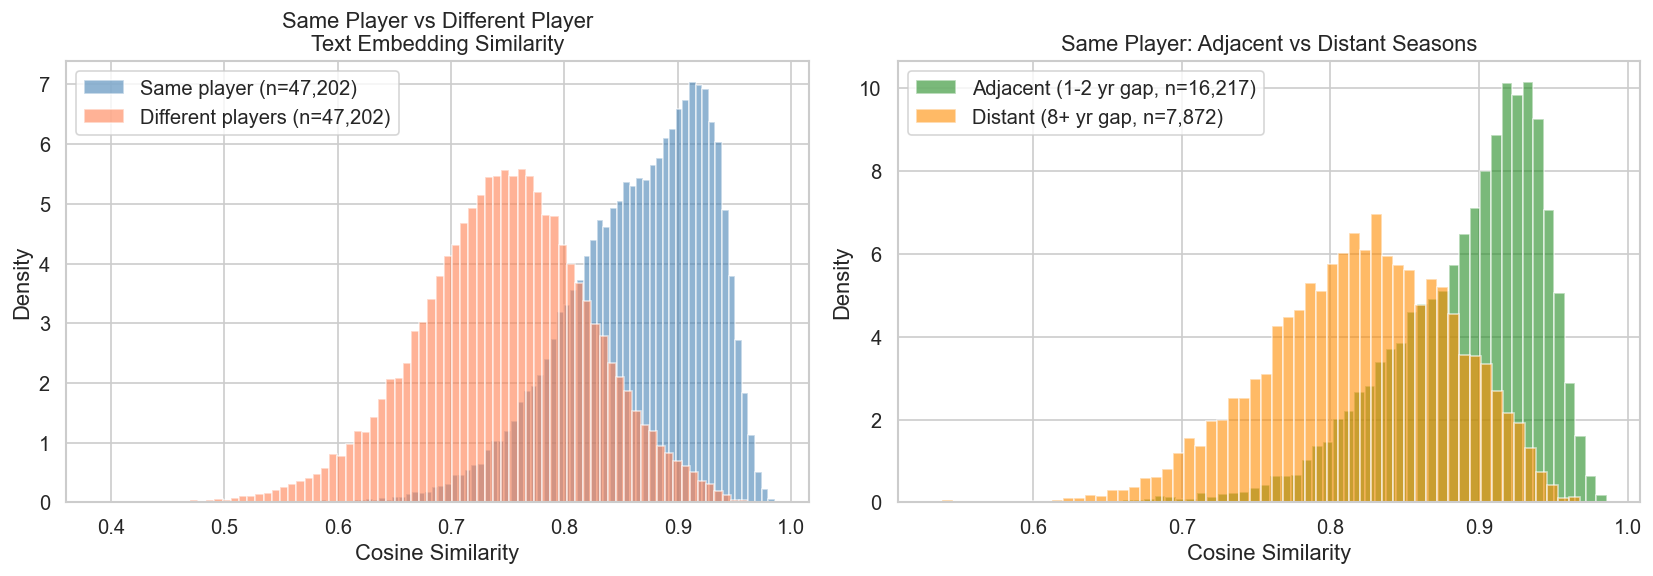

Same player:      mean=0.8651, std=0.0624
Different player: mean=0.7473, std=0.0749
Adjacent seasons: mean=0.8913
Distant seasons:  mean=0.8195

Separation (same - diff): 0.1179


In [4]:
# For each player with 5+ seasons, compute cross-season similarities
multi_season = lu.groupby("player").filter(lambda x: len(x) >= 5)
players_5plus = multi_season["player"].unique()
print(f"Players with 5+ seasons: {len(players_5plus)}")

same_player_sims = []
adjacent_sims = []
distant_sims = []

for player in players_5plus:
    rows = lu[lu["player"] == player].sort_values("season")
    pids = rows["player_season_id"].values
    seasons = rows["season"].values
    
    for i in range(len(pids)):
        for j in range(i+1, len(pids)):
            sim = (emb_norm[pids[i]] @ emb_norm[pids[j]]).item()
            gap = seasons[j] - seasons[i]
            same_player_sims.append(sim)
            if gap <= 2:
                adjacent_sims.append(sim)
            elif gap >= 8:
                distant_sims.append(sim)

# Compare to random different-player pairs
np.random.seed(42)
diff_player_sims = []
for _ in range(len(same_player_sims)):
    i, j = np.random.choice(emb.shape[0], 2, replace=False)
    diff_player_sims.append((emb_norm[i] @ emb_norm[j]).item())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: same vs different player
axes[0].hist(same_player_sims, bins=80, alpha=0.6, label=f"Same player (n={len(same_player_sims):,})", color="steelblue", density=True)
axes[0].hist(diff_player_sims, bins=80, alpha=0.6, label=f"Different players (n={len(diff_player_sims):,})", color="coral", density=True)
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Density")
axes[0].set_title("Same Player vs Different Player\nText Embedding Similarity")
axes[0].legend()

# Right: adjacent seasons vs distant seasons
axes[1].hist(adjacent_sims, bins=60, alpha=0.6, label=f"Adjacent (1-2 yr gap, n={len(adjacent_sims):,})", color="forestgreen", density=True)
if distant_sims:
    axes[1].hist(distant_sims, bins=60, alpha=0.6, label=f"Distant (8+ yr gap, n={len(distant_sims):,})", color="darkorange", density=True)
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Density")
axes[1].set_title("Same Player: Adjacent vs Distant Seasons")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Same player:      mean={np.mean(same_player_sims):.4f}, std={np.std(same_player_sims):.4f}")
print(f"Different player: mean={np.mean(diff_player_sims):.4f}, std={np.std(diff_player_sims):.4f}")
print(f"Adjacent seasons: mean={np.mean(adjacent_sims):.4f}")
if distant_sims:
    print(f"Distant seasons:  mean={np.mean(distant_sims):.4f}")
print(f"\nSeparation (same - diff): {np.mean(same_player_sims) - np.mean(diff_player_sims):.4f}")

## 4. Career Evolution Trajectories

Let's trace specific players through their careers and see how the text embedding captures their evolution. Players who reinvented themselves (Brook Lopez adding a 3-point shot, LeBron moving from athletic slasher to floor general) should show clear movement in embedding space.

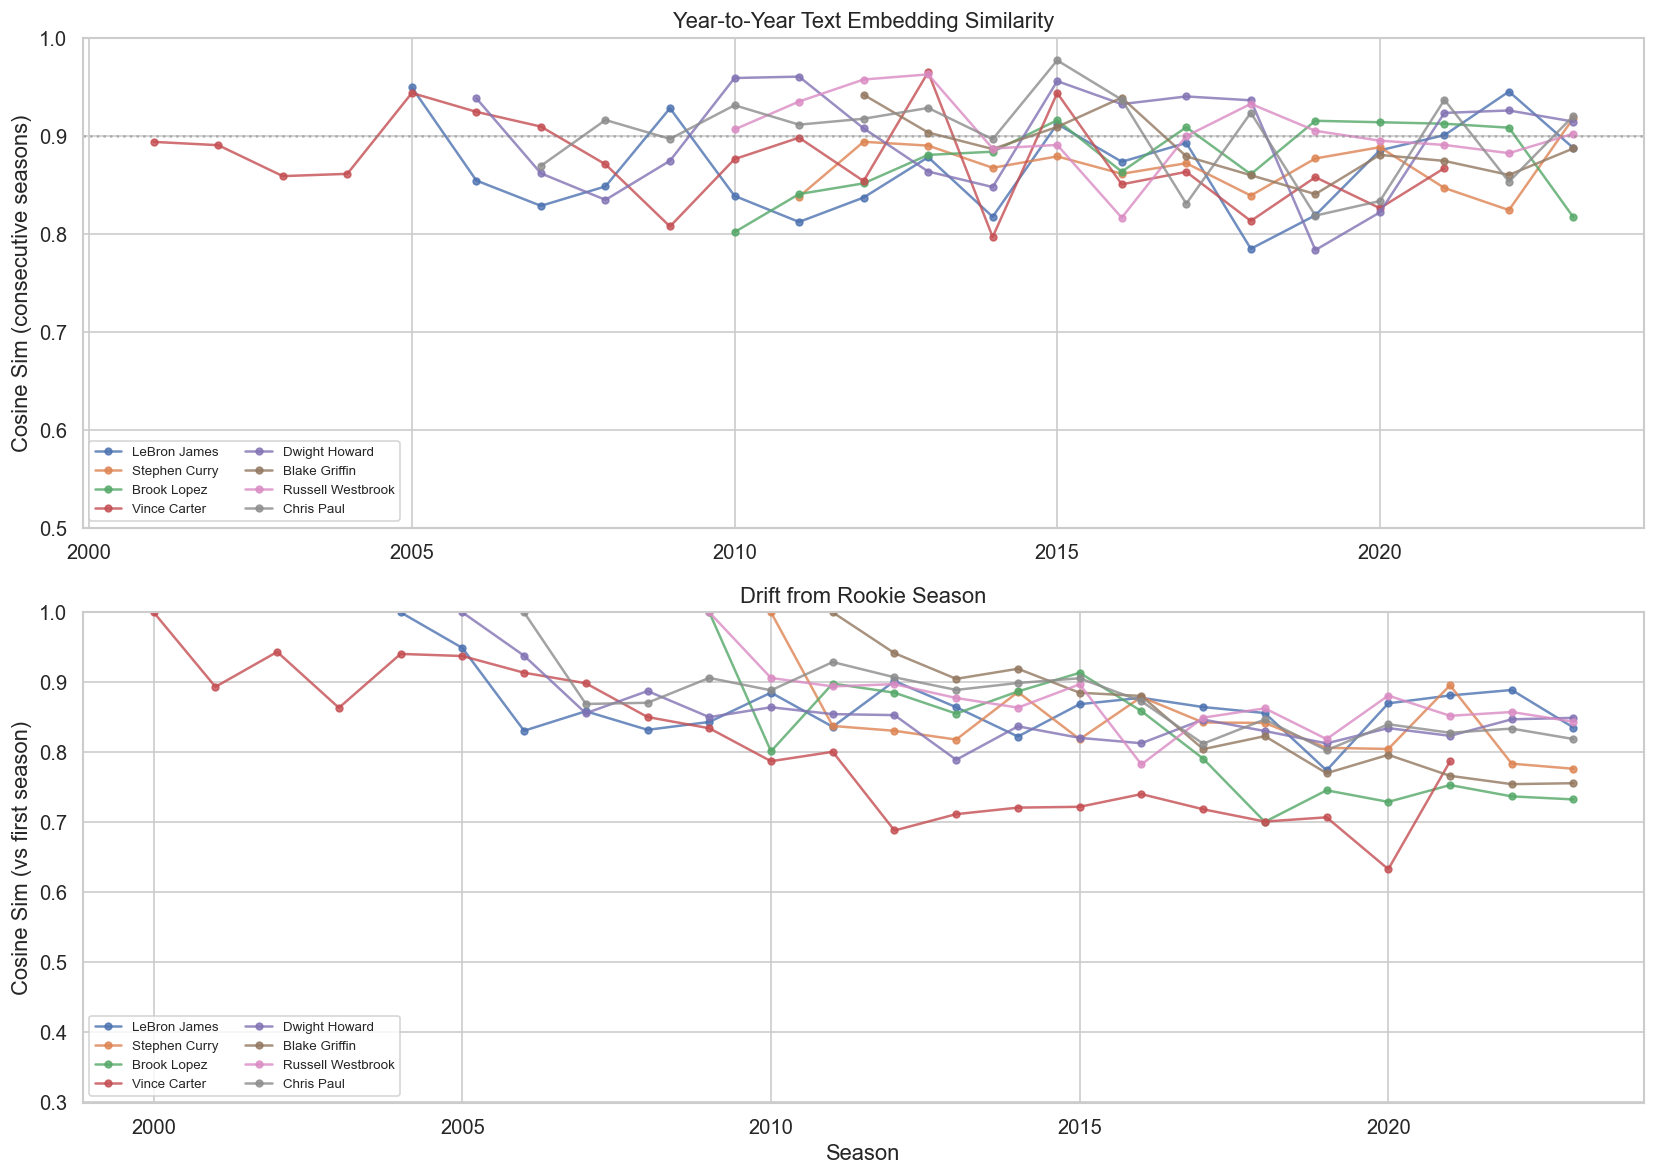


--- Most changed players (largest drift from first to last season) ---
  LeBron James             : first-to-last sim = 0.8354 (20 seasons)
  Stephen Curry            : first-to-last sim = 0.7766 (14 seasons)
  Brook Lopez              : first-to-last sim = 0.7329 (15 seasons)
  Vince Carter             : first-to-last sim = 0.7872 (22 seasons)
  Dwight Howard            : first-to-last sim = 0.8493 (19 seasons)
  Blake Griffin            : first-to-last sim = 0.7560 (13 seasons)
  Russell Westbrook        : first-to-last sim = 0.8438 (15 seasons)
  Chris Paul               : first-to-last sim = 0.8190 (18 seasons)


In [5]:
evolution_players = [
    "jamesle01", "curryst01", "lopezbr01", "cartevi01",
    "howardw01", "griffbl01", "westbru01", "paulch01",
]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for bbref in evolution_players:
    rows = lu[lu["player"] == bbref].sort_values("season")
    if len(rows) < 3:
        continue
    
    dname = display_name(bbref)
    pids = rows["player_season_id"].values
    seasons = rows["season"].values
    
    # Year-to-year similarity
    yty_sims = []
    for i in range(len(pids) - 1):
        sim = (emb_norm[pids[i]] @ emb_norm[pids[i+1]]).item()
        yty_sims.append(sim)
    
    axes[0].plot(seasons[1:], yty_sims, marker="o", markersize=4, label=dname[:20], alpha=0.8)
    
    # Similarity to first season (drift from original archetype)
    drift = [(emb_norm[pids[0]] @ emb_norm[pid]).item() for pid in pids]
    axes[1].plot(seasons, drift, marker="o", markersize=4, label=dname[:20], alpha=0.8)

axes[0].set_title("Year-to-Year Text Embedding Similarity")
axes[0].set_ylabel("Cosine Sim (consecutive seasons)")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(fontsize=8, ncol=2, loc="lower left")
axes[0].axhline(0.9, color="gray", linestyle=":", alpha=0.5)

axes[1].set_title("Drift from Rookie Season")
axes[1].set_ylabel("Cosine Sim (vs first season)")
axes[1].set_xlabel("Season")
axes[1].set_ylim(0.3, 1.0)
axes[1].legend(fontsize=8, ncol=2, loc="lower left")

plt.tight_layout()
plt.show()

# Print the most interesting evolution stories
print("\n--- Most changed players (largest drift from first to last season) ---")
for bbref in evolution_players:
    rows = lu[lu["player"] == bbref].sort_values("season")
    if len(rows) < 3:
        continue
    dname = display_name(bbref)
    pids = rows["player_season_id"].values
    first_last_sim = (emb_norm[pids[0]] @ emb_norm[pids[-1]]).item()
    print(f"  {dname:25s}: first-to-last sim = {first_last_sim:.4f} ({len(rows)} seasons)")

## 5. Read the Descriptions: Spot-Check Quality

Let's actually read what GPT-4o-mini wrote for some key players at key moments. Do the descriptions capture the right things?

In [6]:
spotlight = [
    ("jamesle01", 2004, "LeBron - Rookie Season"),
    ("jamesle01", 2013, "LeBron - Peak Miami"),
    ("jamesle01", 2020, "LeBron - Late-Prime LA"),
    ("curryst01", 2010, "Curry - Early Career (injury concerns)"),
    ("curryst01", 2016, "Curry - Unanimous MVP"),
    ("lopezbr01", 2013, "Brook Lopez - Traditional Center"),
    ("lopezbr01", 2020, "Brook Lopez - Stretch Five"),
    ("howardw01", 2010, "Dwight Howard - DPOY Era"),
    ("howardw01", 2020, "Dwight Howard - Role Player"),
    ("griffbl01", 2012, "Blake Griffin - Lob City"),
    ("griffbl01", 2019, "Blake Griffin - Point Forward"),
]

for player, season, label in spotlight:
    desc = descs.get((player, season))
    if desc:
        print(f"\n{'='*70}")
        print(f"  {label}")
        print(f"{'='*70}")
        print(f"  {desc}")
    else:
        print(f"\n  [{label}] - Not found in descriptions")


  LeBron - Rookie Season
  During the 2004-2005 NBA season, LeBron James was emerging as a versatile playmaker and a dominant force on the court, primarily playing as a small forward but often functioning as a point forward. He was an exceptional floor general, capable of driving the offense with his elite passing and court vision, while also being a potent isolation scorer who could overpower defenders with his athleticism and finish at the rim. Defensively, he was developing into a disruptive presence, using his size and quickness to guard multiple positions, although his defensive awareness and discipline were still maturing. At this stage in his career, LeBron fit best in a team that allowed him to be the focal point of the offense, surrounded by shooters and complementary players who could capitalize on his playmaking abilities and provide defensive support.

  LeBron - Peak Miami
  During the 2013-2014 NBA season, LeBron James was best characterized as a versatile point forward,

## 6. t-SNE Visualization: The Big Picture

Let's project all embeddings down to 2D and color by different attributes. This gives us a bird's-eye view of how the text embedding space is organized.

In [7]:
# Use a random sample for t-SNE (full 12K is slow)
n_tsne = 3000
np.random.seed(42)
tsne_idx = np.random.choice(emb.shape[0], n_tsne, replace=False)

# Also include specific notable players so we can annotate them
notable = [
    "jamesle01", "curryst01", "duranke01", "jokicni01", "doncilu01",
    "howardw01", "greendr01", "rodmade01", "redicjj01", "lopezbr01",
    "hardeja01", "westbru01", "leonaka01", "davisan02",
]
notable_ids = lu[lu["player"].isin(notable)]["player_season_id"].values
tsne_idx = np.unique(np.concatenate([tsne_idx, notable_ids]))
n_tsne = len(tsne_idx)

print(f"Running t-SNE on {n_tsne} embeddings...")
tsne = TSNE(n_components=2, perplexity=40, learning_rate=200,
            init="pca", random_state=42, n_iter=1000)
coords = tsne.fit_transform(emb_norm[tsne_idx].numpy())
print("Done!")

# Get metadata for coloring
seasons = np.array([id_to_season.get(i, 2010) for i in tsne_idx])

Running t-SNE on 3132 embeddings...


/Users/nbrown1/Desktop/unicorn/.unicorn/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Done!


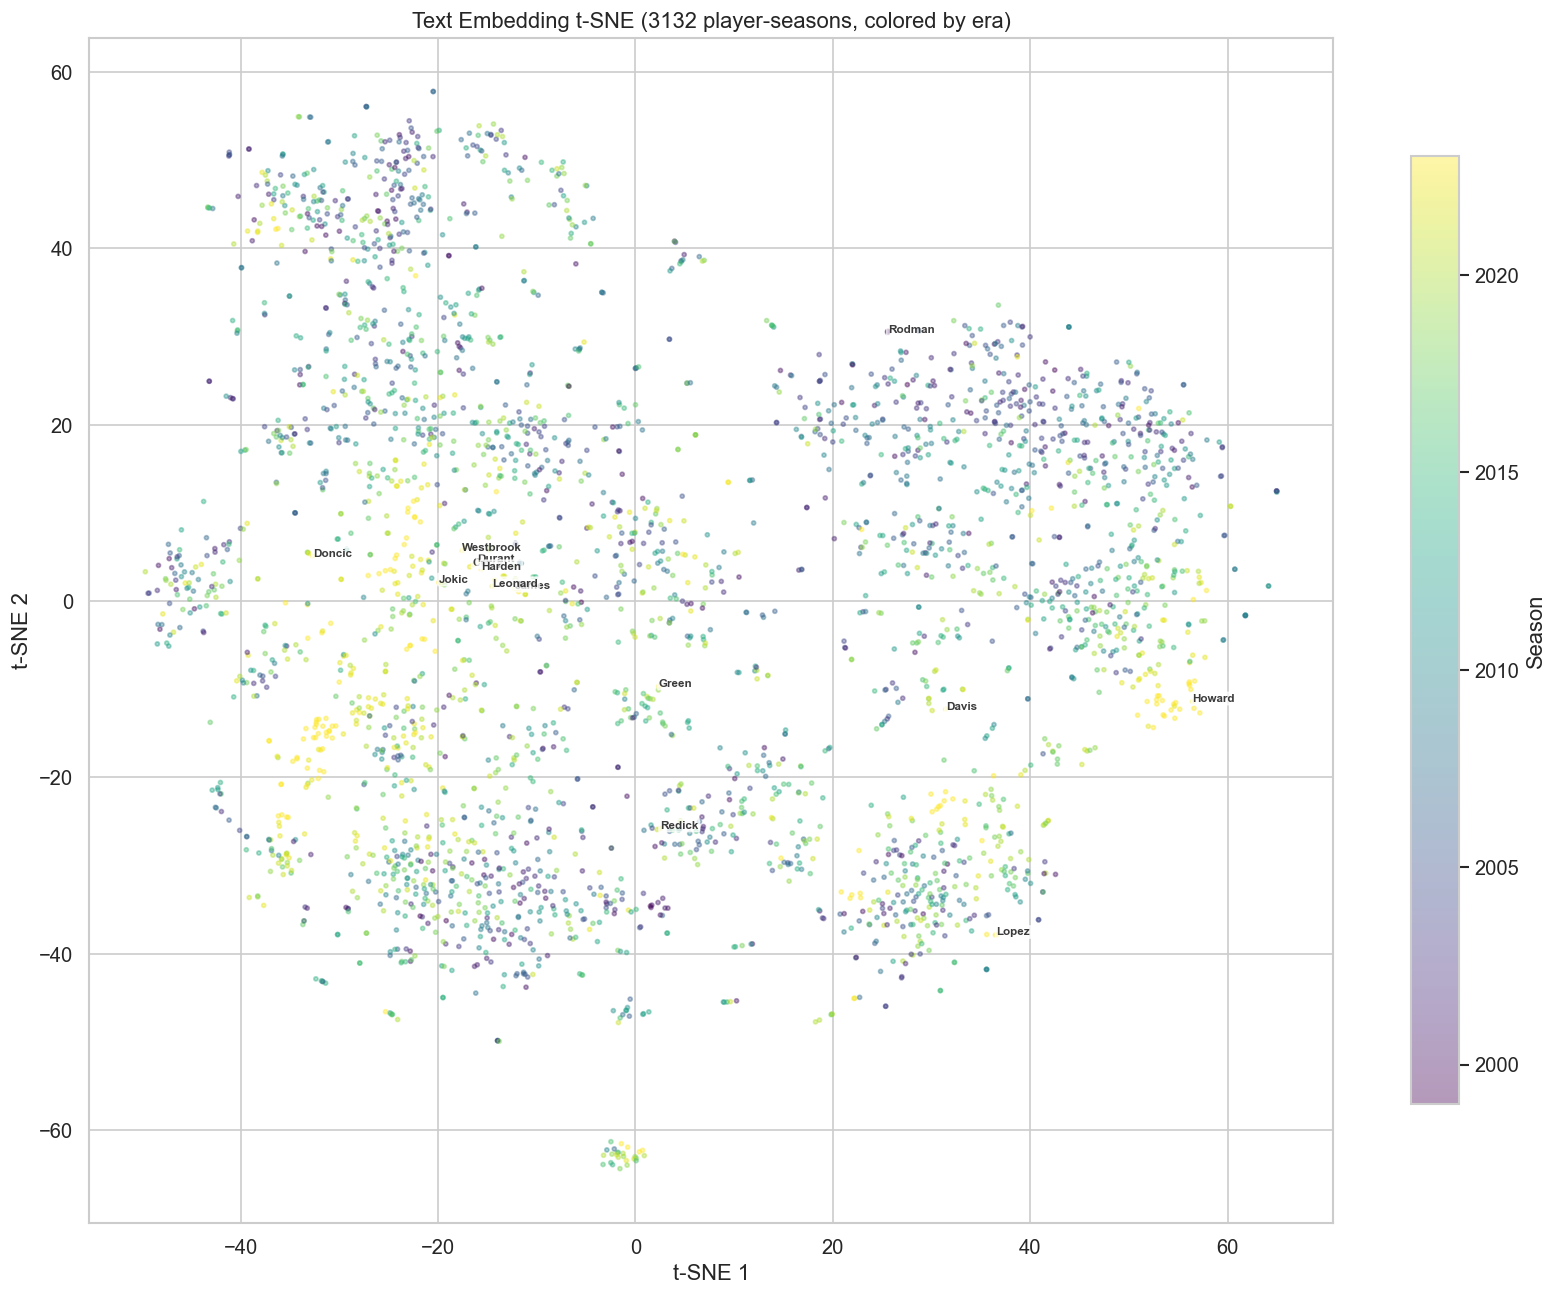

In [8]:
fig, ax = plt.subplots(figsize=(14, 11))

scatter = ax.scatter(coords[:, 0], coords[:, 1], c=seasons,
                     cmap="viridis", s=6, alpha=0.4)
plt.colorbar(scatter, label="Season", shrink=0.8)

# Annotate notable players (most recent season only) with display names
for player in notable:
    rows = lu[lu["player"] == player].sort_values("season")
    if len(rows) == 0:
        continue
    latest = rows.iloc[-1]
    pid = latest["player_season_id"]
    mask_idx = np.where(tsne_idx == pid)[0]
    if len(mask_idx) > 0:
        idx = mask_idx[0]
        dname = display_name(player)
        # Use last name for compact annotation
        short = dname.split()[-1] if " " in dname else dname[:12]
        ax.annotate(short, (coords[idx, 0], coords[idx, 1]),
                   fontsize=7, fontweight="bold", alpha=0.9,
                   bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7))

ax.set_title(f"Text Embedding t-SNE ({n_tsne} player-seasons, colored by era)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 7. Archetype Clustering

Let's use K-means to find natural clusters in the text embedding space and see what archetypes emerge. If the clusters correspond to basketball roles (shooters, bigs, playmakers, etc.), the space has good structure.

In [9]:
# K-means on full embedding space
n_clusters = 8
print(f"Running K-means with {n_clusters} clusters...")
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = km.fit_predict(emb_norm.numpy())

# For each cluster, show representative players (closest to centroid)
centroids = torch.from_numpy(km.cluster_centers_).float()
centroids_norm = F.normalize(centroids, dim=1)

print(f"\n{'='*70}")
print(f"ARCHETYPE CLUSTERS (K={n_clusters})")
print(f"{'='*70}")

for c in range(n_clusters):
    cluster_mask = labels == c
    cluster_ids = np.where(cluster_mask)[0]
    
    # Closest to centroid
    sims = (emb_norm[cluster_ids] @ centroids_norm[c]).numpy()
    top_idx = np.argsort(-sims)[:8]
    
    print(f"\n  Cluster {c} ({cluster_mask.sum()} players):")
    for idx in top_idx:
        pid = cluster_ids[idx]
        print(f"    {id_to_name.get(pid, f'ID_{pid}'):35s} sim={sims[idx]:.4f}")
    
    # Print one representative description
    rep_pid = cluster_ids[top_idx[0]]
    rep_player = id_to_player.get(rep_pid)
    rep_season = id_to_season.get(rep_pid)
    desc = descs.get((rep_player, rep_season), "")
    if desc:
        print(f"    >> {desc[:150]}...")

Running K-means with 8 clusters...

ARCHETYPE CLUSTERS (K=8)

  Cluster 0 (2609 players):
    Garrett Temple (2017)               sim=0.9781
    Robert Covington (2020)             sim=0.9777
    Josh Hart (2018)                    sim=0.9774
    Jarvis Hayes (2009)                 sim=0.9774
    Greg Whittington (2022)             sim=0.9767
    Mickaël Piétrus (2011)              sim=0.9764
    C.J. Miles (2011)                   sim=0.9763
    Tony Snell (2021)                   sim=0.9761
    >> During the 2017-2018 NBA season, Garrett Temple was primarily identified as a 3-and-D wing, known for his ability to contribute both offensively and d...

  Cluster 1 (1715 players):
    Victor Oladipo (2015)               sim=0.9615
    Evan Turner (2014)                  sim=0.9521
    DeAndre' Bembry (2019)              sim=0.9514
    Josh Howard (2005)                  sim=0.9498
    James Johnson (2013)                sim=0.9488
    Blake Griffin (2016)                sim=0.9473
    Jo


ARCHETYPE CLUSTERS (K=8)

  Cluster 0 (2609 players):
    Garrett Temple (2017)               sim=0.9781
    Robert Covington (2020)             sim=0.9777
    Josh Hart (2018)                    sim=0.9774
    Jarvis Hayes (2009)                 sim=0.9774
    Greg Whittington (2022)             sim=0.9767
    Mickaël Piétrus (2011)              sim=0.9764
    C.J. Miles (2011)                   sim=0.9763
    Tony Snell (2021)                   sim=0.9761
    >> During the 2017-2018 NBA season, Garrett Temple was primarily identified as a 3-and-D wing, known for his ability to contribute both offensively and d...

  Cluster 1 (1715 players):
    Victor Oladipo (2015)               sim=0.9615
    Evan Turner (2014)                  sim=0.9521
    DeAndre' Bembry (2019)              sim=0.9514
    Josh Howard (2005)                  sim=0.9498
    James Johnson (2013)                sim=0.9488
    Blake Griffin (2016)                sim=0.9473
    Josh Jackson (2020)                 s

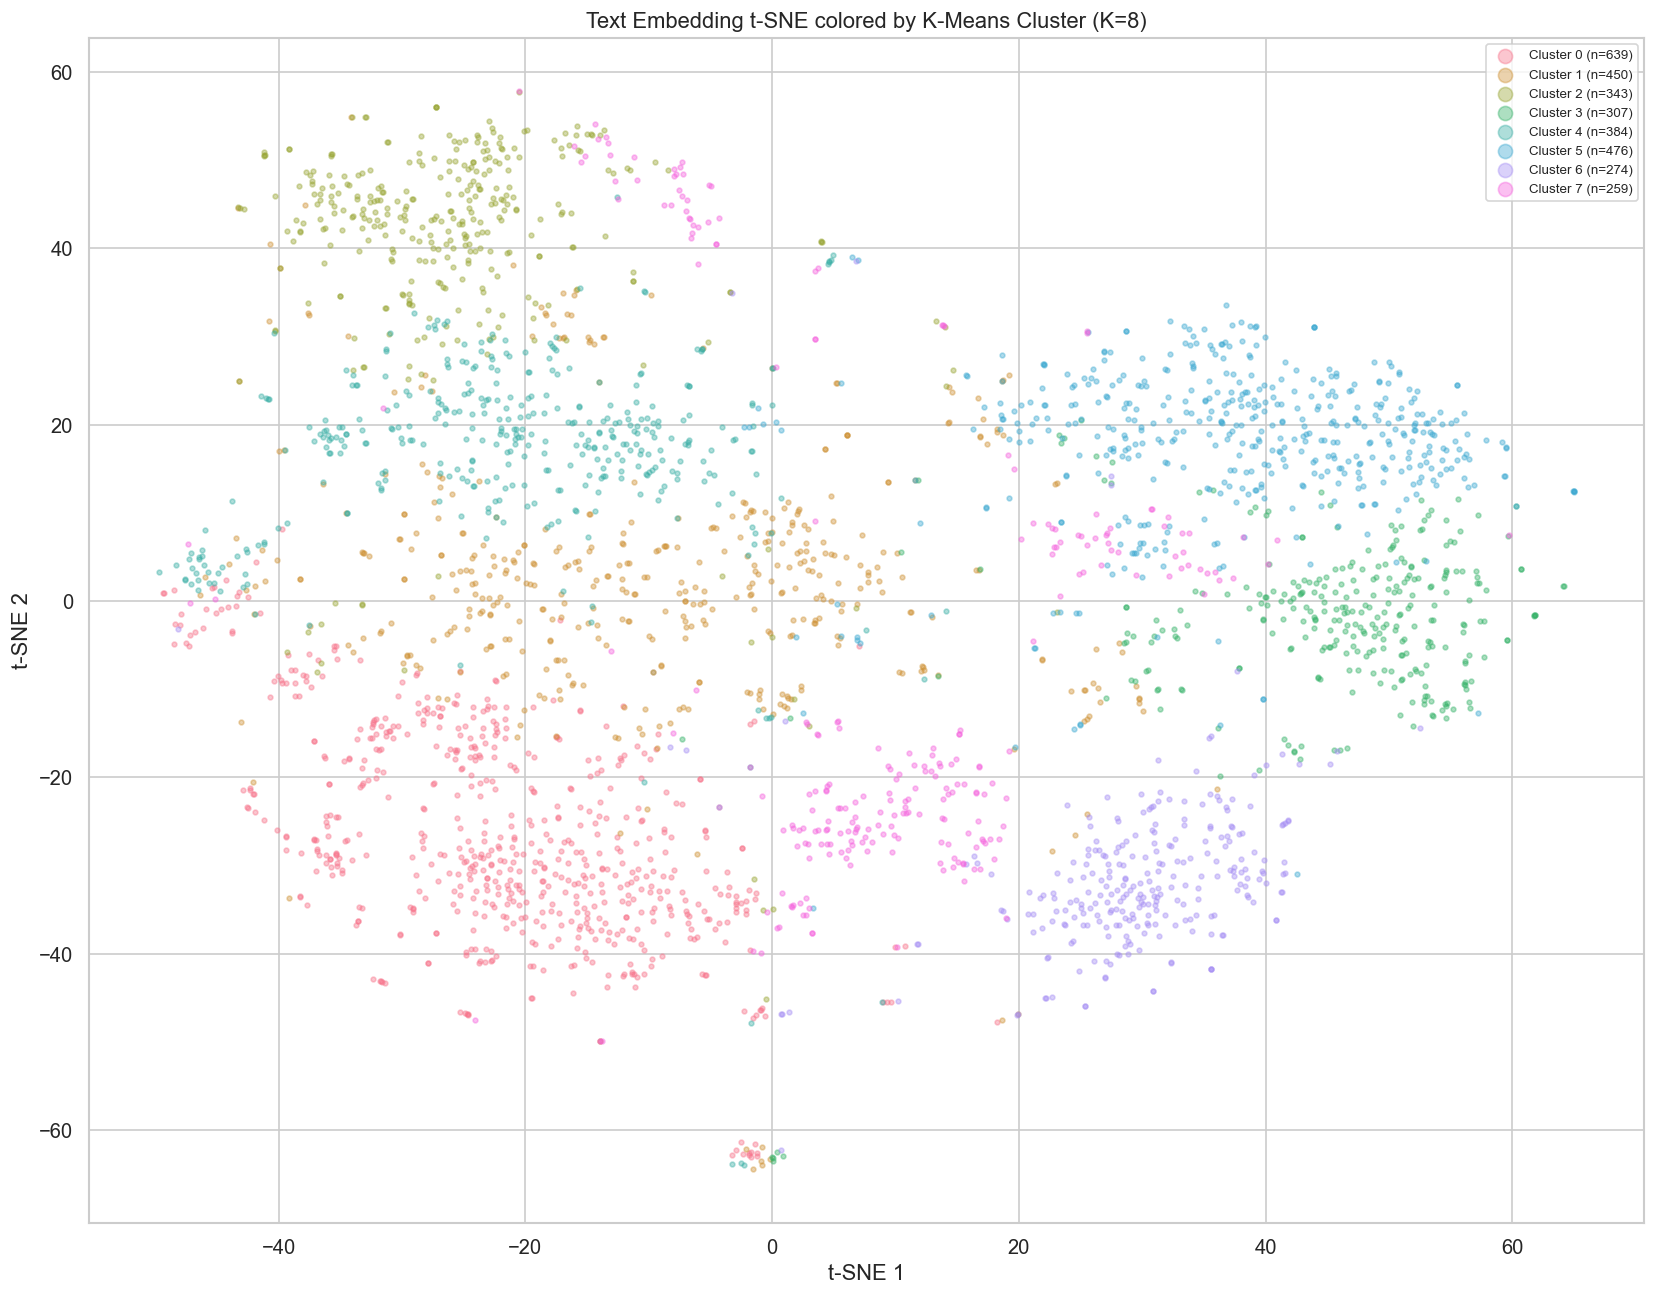

In [10]:
# Visualize clusters on t-SNE
tsne_labels = labels[tsne_idx]

fig, ax = plt.subplots(figsize=(14, 11))
palette = sns.color_palette("husl", n_clusters)

for c in range(n_clusters):
    mask = tsne_labels == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
              color=palette[c], s=8, alpha=0.4, label=f"Cluster {c} (n={mask.sum()})")

ax.set_title(f"Text Embedding t-SNE colored by K-Means Cluster (K={n_clusters})")
ax.legend(fontsize=8, markerscale=3, loc="best")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 8. Cross-Era Comparisons

One of the most interesting things about basketball embeddings: can we find players from different eras who played similarly? The text descriptions should capture archetype similarity across time.

In [11]:
# Cross-era archetype matching
cross_era_pairs = [
    # Floor generals
    ("nashst01", 2005, "paulch01", 2008, "Floor Generals"),
    # Athletic wing scorers
    ("cartevi01", 2001, "edwaran01", 2022, "Athletic Wing Scorers"),
    # Stretch bigs
    ("nowitdi01", 2006, "townska01", 2019, "Stretch Bigs"),
    # Defensive anchors
    ("wallabe01", 2004, "greendr01", 2016, "Defensive Anchors"),
    # Volume scorers
    ("iversal01", 2001, "westbru01", 2017, "Volume Scorers"),
    # Playmaking bigs
    ("diawbo01", 2014, "jokicni01", 2023, "Playmaking Bigs"),
]

print(f"{'='*70}")
print("CROSS-ERA ARCHETYPE COMPARISONS")
print(f"{'='*70}")

for p1, s1, p2, s2, label in cross_era_pairs:
    m1 = lu[(lu["player"] == p1) & (lu["season"] == s1)]
    m2 = lu[(lu["player"] == p2) & (lu["season"] == s2)]
    if len(m1) == 0 or len(m2) == 0:
        print(f"  {label}: player not found")
        continue
    
    id1 = m1.iloc[0]["player_season_id"]
    id2 = m2.iloc[0]["player_season_id"]
    sim = (emb_norm[id1] @ emb_norm[id2]).item()
    
    n1 = f"{display_name(p1)} ({s1})"
    n2 = f"{display_name(p2)} ({s2})"
    print(f"\n  {label}:")
    print(f"    {n1} vs {n2}: sim = {sim:.4f}")

CROSS-ERA ARCHETYPE COMPARISONS

  Floor Generals:
    Steve Nash (2005) vs Chris Paul (2008): sim = 0.8540

  Athletic Wing Scorers:
    Vince Carter (2001) vs Anthony Edwards (2022): sim = 0.8136

  Stretch Bigs:
    Dirk Nowitzki (2006) vs Karl-Anthony Towns (2019): sim = 0.9114

  Defensive Anchors:
    Ben Wallace (2004) vs Draymond Green (2016): sim = 0.6638

  Volume Scorers:
    Allen Iverson (2001) vs Russell Westbrook (2017): sim = 0.8040

  Playmaking Bigs:
    Boris Diaw (2014) vs Nikola Jokic (2023): sim = 0.8172


## 9. Failure Mode Analysis: Where the Text Embeddings Go Wrong

Text embeddings have known limitations:
- They can't distinguish players the LLM doesn't know well (obscure bench players)
- They may conflate players who sound similar in text but play differently  
- They can't capture lineup-dependent context (how a player plays WITH specific teammates)

Let's quantify these issues.

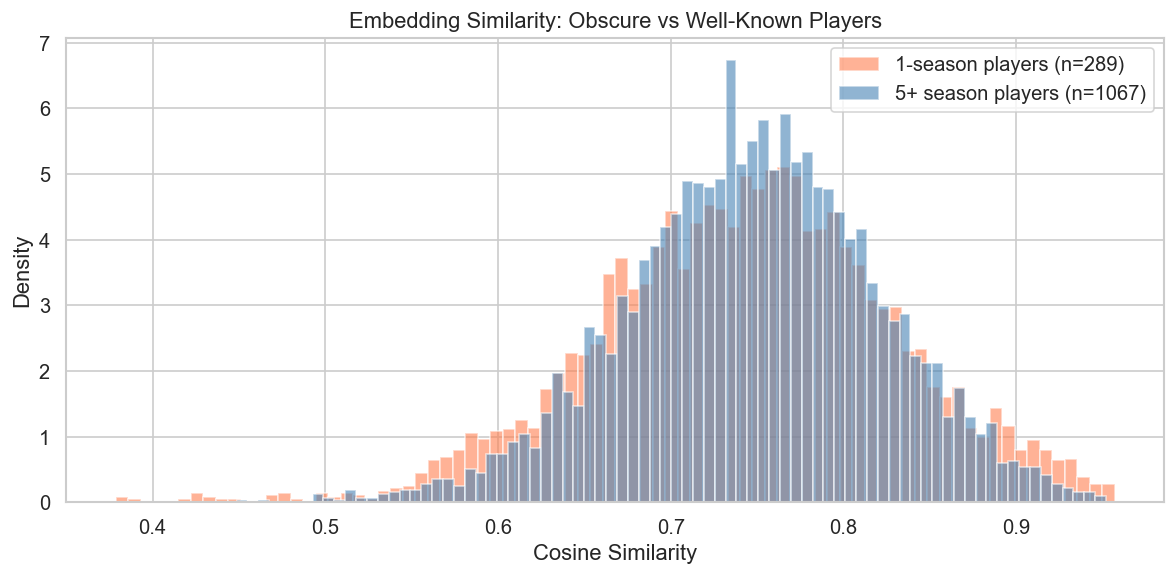

Obscure (1-season) mean sim:  0.7430
Known (5+ season) mean sim:   0.7478

If obscure players are MORE similar to each other, it means the LLM
is giving them generic descriptions. The delta_emb and training will need
to differentiate them — which is fine, that's what the model is for.


In [12]:
# 1. How similar are 'obscure' players to each other?
# Use players who appear in only 1 season as a proxy for obscurity
season_counts = lu.groupby("player")["season"].count()
one_season = season_counts[season_counts == 1].index.tolist()
multi_season_players = season_counts[season_counts >= 5].index.tolist()

# Sample pairwise sims among 1-season players
one_season_ids = lu[lu["player"].isin(one_season)]["player_season_id"].values
multi_ids = lu[lu["player"].isin(multi_season_players)]["player_season_id"].values

np.random.seed(42)
n_pairs = 5000

def sample_pairwise_sims(ids, n=n_pairs):
    pairs_i = np.random.choice(ids, n)
    pairs_j = np.random.choice(ids, n)
    sims = [(emb_norm[i] @ emb_norm[j]).item() for i, j in zip(pairs_i, pairs_j) if i != j]
    return sims

obscure_sims = sample_pairwise_sims(one_season_ids)
known_sims = sample_pairwise_sims(multi_ids)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(obscure_sims, bins=80, alpha=0.6, label=f"1-season players (n={len(one_season)})", color="coral", density=True)
ax.hist(known_sims, bins=80, alpha=0.6, label=f"5+ season players (n={len(multi_season_players)})", color="steelblue", density=True)
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Density")
ax.set_title("Embedding Similarity: Obscure vs Well-Known Players")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Obscure (1-season) mean sim:  {np.mean(obscure_sims):.4f}")
print(f"Known (5+ season) mean sim:   {np.mean(known_sims):.4f}")
print(f"\nIf obscure players are MORE similar to each other, it means the LLM")
print(f"is giving them generic descriptions. The delta_emb and training will need")
print(f"to differentiate them — which is fine, that's what the model is for.")

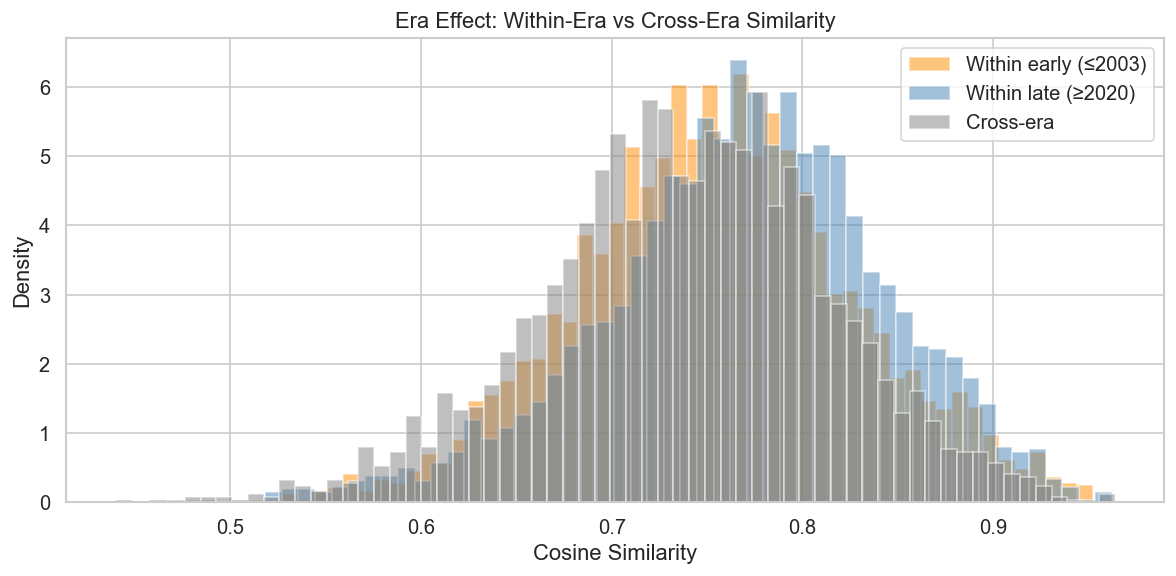

Within early (≤2003): mean=0.7544
Within late (≥2020):  mean=0.7689
Cross-era:            mean=0.7384


In [13]:
# 2. Era effect: are early-2000s descriptions more similar to each other
# than to 2020s descriptions? (Could indicate LLM bias toward recency)
early_ids = lu[lu["season"] <= 2003]["player_season_id"].values
late_ids = lu[lu["season"] >= 2020]["player_season_id"].values

early_sims = sample_pairwise_sims(early_ids, 3000)
late_sims = sample_pairwise_sims(late_ids, 3000)

# Cross-era sims
cross_sims = []
for _ in range(3000):
    i = np.random.choice(early_ids)
    j = np.random.choice(late_ids)
    cross_sims.append((emb_norm[i] @ emb_norm[j]).item())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(early_sims, bins=60, alpha=0.5, label=f"Within early (≤2003)", density=True, color="darkorange")
ax.hist(late_sims, bins=60, alpha=0.5, label=f"Within late (≥2020)", density=True, color="steelblue")
ax.hist(cross_sims, bins=60, alpha=0.5, label=f"Cross-era", density=True, color="gray")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Density")
ax.set_title("Era Effect: Within-Era vs Cross-Era Similarity")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Within early (≤2003): mean={np.mean(early_sims):.4f}")
print(f"Within late (≥2020):  mean={np.mean(late_sims):.4f}")
print(f"Cross-era:            mean={np.mean(cross_sims):.4f}")

## 10. Base Player Embeddings: The Initialization for Training

The `base_player_emb` (2,310 unique players) is what actually gets loaded into the model. It's the average of all season-specific text embeddings, scaled to a target std of 0.02. Let's look at its properties.

In [14]:
# Re-normalize base embeddings for similarity analysis
base_norm = F.normalize(base_emb, dim=1)

# Build base player name mapping
from prior_year_init import build_base_player_mapping
ps_to_base, num_base = build_base_player_mapping()

# Invert: base_id → bbref player ID (pick first occurrence)
base_to_player = {}
for _, row in lu.iterrows():
    ps_id = int(row["player_season_id"])
    if ps_id in ps_to_base:
        base_id = ps_to_base[ps_id]
        if base_id not in base_to_player:
            base_to_player[base_id] = row["player"]

def base_display(base_id):
    """Get display name for a base player ID."""
    bbref = base_to_player.get(base_id, f"ID_{base_id}")
    return display_name(bbref)

print(f"Base player embeddings: {base_emb.shape}")
print(f"Std: {base_emb.std():.4f} (target: 0.02)")
print(f"Norm: mean={base_emb.norm(dim=1).mean():.4f}, std={base_emb.norm(dim=1).std():.4f}")

# Nearest neighbors in base space
base_queries = ["jamesle01", "curryst01", "jokicni01", "greendr01", "redicjj01", "rodmade01"]

for player in base_queries:
    base_id = None
    for bid, p in base_to_player.items():
        if p == player:
            base_id = bid
            break
    if base_id is None:
        continue
    
    sims = (base_norm @ base_norm[base_id]).numpy()
    top_ids = np.argsort(-sims)[1:7]  # skip self
    
    print(f"\n  {display_name(player)} (base):")
    for tid in top_ids:
        print(f"    {base_display(tid):30s} sim={sims[tid]:.4f}")

Base player embeddings: torch.Size([2310, 384])
Std: 0.0200 (target: 0.02)
Norm: mean=0.3919, std=0.0098

  LeBron James (base):
    Justise Winslow                sim=0.9525
    Jimmy Butler                   sim=0.9519
    Jrue Holiday                   sim=0.9480
    Lamar Odom                     sim=0.9463
    Ben Simmons                    sim=0.9436
    Gordon Hayward                 sim=0.9432

  Stephen Curry (base):
    Seth Curry                     sim=0.9437
    Ray Allen                      sim=0.9376
    Bradley Beal                   sim=0.9369
    Buddy Hield                    sim=0.9354
    Malik Beasley                  sim=0.9341
    Luke Kennard                   sim=0.9340

  Nikola Jokic (base):
    Jamal Murray                   sim=0.8957
    Domantas Sabonis               sim=0.8912
    Marc Gasol                     sim=0.8775
    LeBron James                   sim=0.8761
    Brad Miller                    sim=0.8749
    Nikola Vucevic                 sim=0

## Summary & Takeaways

**What we should look for:**
1. **Same-player coherence**: Same player across seasons should be notably more similar than random pairs.
2. **Archetype clustering**: Clusters should roughly correspond to player types (guards, bigs, wings, etc.).
3. **Career evolution**: Players who changed their game (Lopez, Griffin) should show meaningful drift.
4. **Cross-era archetypes**: Similar players from different eras should be close.
5. **No collapse**: Pairwise similarity should NOT be uniformly high.
6. **No name bias**: Curry's neighbors should be elite shooters (Nash, Lillard), NOT Seth Curry / Eddy Curry.
7. **No era bias**: t-SNE should NOT show clear era gradient as the dominant structure.

**Remember:** These are anonymized text embeddings — player names and year references have been stripped before embedding. This should eliminate the name-string and year/era biases that dominated the v1 text embeddings. The Unicorn v2 model will learn *from actual play-by-play data*, using these as a starting point.